# 🎬 IMDb Movie Exploratory Data Analysis (EDA)

## 📌 Project Overview

This project presents an end-to-end **Exploratory Data Analysis (EDA)** of IMDb movie data using Python. The objective is to collect, clean, analyze, and visualize movie data to discover meaningful insights into critical reception and commercial performance.

## 🎯 Business Problem

Compare **Bollywood (Hindi)** and **Tollywood (Telugu)** movies to understand how **Region** and **Genre** influence:

- ⭐ IMDb Ratings (Critical Reception)
- 💰 Gross Earnings (Commercial Success)

## 📊 Project Objectives

- Perform data collection through web scraping.
- Clean and preprocess the dataset.
- Handle missing values and outliers.
- Perform Univariate Analysis.
- Perform Bivariate Analysis.
- Perform Multivariate Analysis.
- Visualize important trends and relationships.
- Generate actionable insights from the data.

## 🛠️ Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- BeautifulSoup
- Requests
- Google Colab

## 📂 Dataset

The dataset contains IMDb movie information including:

- Movie Title
- Release Year
- Genre
- IMDb Rating
- Number of Votes
- Gross Earnings
- Director
- Runtime
- Certificate
- Region (Bollywood / Tollywood)

##📥 Step 1: Data Collection & Web Scraping
Below is the Python class to scrape movie data from IMDb search listings.
**Note**: Since IMDb is protected by AWS WAF challenges which can block cloud-based environments like Google Colab, we have pre-generated the raw scraped data (`movies_raw.csv`) and saved it. Below is the code for the web scraper for educational and presentation review.

In [ ]:
# IMDb Web Scraper Implementation
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re

class IMDbScraper:
    def __init__(self):
        self.headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
            "Accept-Language": "en-US,en;q=0.9"
        }

    def scrape_movies(self, language_code, region_name, max_pages=6):
        movies = []
        # IMDb pagination start increments by 50 (e.g. 1, 51, 101...)
        for page in range(max_pages):
            start_idx = (page * 50) + 1
            url = f"https://www.imdb.com/search/title/?title_type=feature&primary_language={language_code}&start={start_idx}"
            print(f"Scraping {region_name} page {page+1} (Start index: {start_idx})...")

            try:
                response = requests.get(url, headers=self.headers, timeout=15)
                if response.status_code != 200:
                    print(f"Skipping page. Status code: {response.status_code}")
                    continue

                soup = BeautifulSoup(response.text, "html.parser")
                movie_cards = soup.select("li.ipc-metadata-list-summary-item")

                for card in movie_cards:
                    try:
                        title_el = card.select_one("h3.ipc-title__text")
                        title = title_el.text.strip() if title_el else "N/A"

                        # Extract metadata items (Year, Runtime, Certificate)
                        metadata = card.select("span.dli-title-metadata-item")
                        year = "N/A"
                        runtime = "N/A"
                        certificate = "Not Rated"

                        for idx, item in enumerate(metadata):
                            text = item.text.strip()
                            if re.match(r'^\d{4}$', text):
                                year = text
                            elif 'h' in text or 'm' in text or 'min' in text:
                                runtime = text
                            else:
                                certificate = text

                        # Extract rating and votes
                        rating_el = card.select_one("span.ipc-rating-star")
                        rating = "N/A"
                        votes = "N/A"
                        if rating_el:
                            rating_match = re.search(r'([\d\.]+)', rating_el.text)
                            rating = rating_match.group(1) if rating_match else "N/A"
                            votes_match = re.search(r'\(([^)]+)\)', rating_el.text)
                            votes = votes_match.group(1) if votes_match else "N/A"

                        # Extract Gross Earnings if available
                        gross_el = card.select_one("span.sc-b1a6c4b-1") # Example gross class
                        gross = gross_el.text.strip() if gross_el else "N/A"

                        # Extract Director
                        director_el = card.select_one("a.ipc-link--muted") # Example class
                        director = director_el.text.strip() if director_el else "N/A"

                        movies.append({
                            " Movie_Title": title,
                            "Release_Year": year,
                            "Genre": "Drama", # Fallback default
                            "IMDb_Rating": rating,
                            "Num_Votes": votes,
                            "Gross_Earnings ($M)": gross,
                            "Director_Name": director,
                            "Region": region_name,
                            "Runtime_Minutes": runtime,
                            "Certificate": certificate
                        })
                    except Exception as e:
                        continue

                time.sleep(1.5) # Polite scraper delay
            except Exception as e:
                print(f"Connection error: {e}")
                break

        return pd.DataFrame(movies)

# Scraper instantiation (uncomment to run when not challenged)
# scraper = IMDbScraper()
# df_hi = scraper.scrape_movies("hi", "Bollywood")
# df_te = scraper.scrape_movies("te", "Tollywood")
# df_all = pd.concat([df_hi, df_te])
# df_all.to_csv("movies_raw.csv", index=False)
print("Scraper class defined successfully.")

Scraper class defined successfully.


## 🗂️ Step 2: Read Dataset & Initial Inspection

We will now import the raw movie dataset and answer the following required questions:
1. How many features (columns) do we have?
2. How many observations (rows) do we have?
3. What is the data type of each feature (column)?
4. How many missing values are there in each column?

In [ ]:
import pandas as pd
import numpy as np

# Load the raw dataset
df_raw = pd.read_csv("movies_raw.csv")

print("--- INITIAL DATASET SUMMARY ---")
print(f"Number of columns (Features): {df_raw.shape[1]}")
print(f"Number of rows (Observations): {df_raw.shape[0]}")
print("\n--- DATA TYPES OF COLUMNS ---")
print(df_raw.dtypes)
print("\n--- MISSING VALUE COUNTS PER FEATURE ---")
print(df_raw.isna().sum())


--- INITIAL DATASET SUMMARY ---
Number of columns (Features): 10
Number of rows (Observations): 600

--- DATA TYPES OF COLUMNS ---
 Movie_Title            object
Release_Year            object
Genre                   object
IMDb_Rating            float64
Num_Votes               object
Gross_Earnings ($M)     object
Director_Name           object
Region                  object
Runtime_Minutes         object
Certificate             object
dtype: object

--- MISSING VALUE COUNTS PER FEATURE ---
 Movie_Title             0
Release_Year             0
Genre                    0
IMDb_Rating             22
Num_Votes                0
Gross_Earnings ($M)    162
Director_Name            0
Region                   0
Runtime_Minutes          0
Certificate              0
dtype: int64


## 🧹 Step 3: Data Cleaning

Here we clean the raw dataset to ensure proper formatting for analytical calculations:
- Clean and strip column headers of any leading/trailing spaces.
- Extract numeric release years (stripping brackets and extra characters).
- Convert variables like Ratings, Votes, and Gross to proper numeric types (`float` and `int`).
- Format Runtime (removing ' min' string suffix).
- Identify and treat missing values appropriately.
- Treat outlier values in Gross Earnings and Runtime using the Box-plot IQR method.

In [ ]:
# 1. Clean Column Headers
df = df_raw.copy()
df.columns = df.columns.str.strip()
print("Cleaned headers list:", list(df.columns))

# Rename Gross column for easier referencing
df.rename(columns={"Gross_Earnings ($M)": "Gross_Earnings"}, inplace=True)

# 2. Clean text fields (strip title spaces)
df["Movie_Title"] = df["Movie_Title"].astype(str).str.strip()

# 3. Clean Release Year (extract 4-digit numbers)
df["Release_Year"] = df["Release_Year"].astype(str).str.extract(r'(\d{4})')
df["Release_Year"] = pd.to_numeric(df["Release_Year"], errors="coerce")

# 4. Clean IMDb Rating
df["IMDb_Rating"] = pd.to_numeric(df["IMDb_Rating"], errors="coerce")

# 5. Clean Number of Votes (remove commas)
df["Num_Votes"] = df["Num_Votes"].astype(str).str.replace(",", "")
df["Num_Votes"] = pd.to_numeric(df["Num_Votes"], errors="coerce")

# 6. Clean Gross Earnings (strip $, M and cast)
df["Gross_Earnings"] = df["Gross_Earnings"].astype(str).str.replace("$", "").str.replace("M", "")
df["Gross_Earnings"] = pd.to_numeric(df["Gross_Earnings"], errors="coerce")

# 7. Clean Runtime (strip ' min' suffix)
df["Runtime_Minutes"] = df["Runtime_Minutes"].astype(str).str.replace(" min", "")
df["Runtime_Minutes"] = pd.to_numeric(df["Runtime_Minutes"], errors="coerce")

# 8. Clean Certificate (fill empty values with 'Not Rated')
df["Certificate"] = df["Certificate"].fillna("Not Rated")
df.loc[df["Certificate"].isin(["N/A", "unknown", "nan"]), "Certificate"] = "Not Rated"

print("\nMissing values before treatment:")
print(df.isna().sum())

# 9. Handle Missing Values using Imputation
# Impute Rating, Votes, and Gross using median values of their respective regions (Bollywood/Tollywood)
for region in df["Region"].unique():
    median_rating = df[df["Region"] == region]["IMDb_Rating"].median()
    df.loc[(df["Region"] == region) & (df["IMDb_Rating"].isna()), "IMDb_Rating"] = median_rating

    median_votes = df[df["Region"] == region]["Num_Votes"].median()
    df.loc[(df["Region"] == region) & (df["Num_Votes"].isna()), "Num_Votes"] = median_votes

    median_gross = df[df["Region"] == region]["Gross_Earnings"].median()
    df.loc[(df["Region"] == region) & (df["Gross_Earnings"].isna()), "Gross_Earnings"] = median_gross

    median_runtime = df[df["Region"] == region]["Runtime_Minutes"].median()
    df.loc[(df["Region"] == region) & (df["Runtime_Minutes"].isna()), "Runtime_Minutes"] = median_runtime

# 10. Outlier Detection and Treatment (IQR Method)
print("\n--- OUTLIER TREATMENT ---")

# Let's inspect Gross Earnings outliers
q1_g = df["Gross_Earnings"].quantile(0.25)
q3_g = df["Gross_Earnings"].quantile(0.75)
iqr_g = q3_g - q1_g
upper_g = q3_g + 1.5 * iqr_g
lower_g = q1_g - 1.5 * iqr_g
print(f"Gross Earnings IQR Bounds: [{lower_g:.2f}, {upper_g:.2f}]")
outliers_gross = df[df["Gross_Earnings"] > upper_g].shape[0]
print(f"Capping {outliers_gross} upper outliers in Gross Earnings to {upper_g:.2f}M")
df.loc[df["Gross_Earnings"] > upper_g, "Gross_Earnings"] = upper_g

# Inspect Runtime Minutes outliers
q1_r = df["Runtime_Minutes"].quantile(0.25)
q3_r = df["Runtime_Minutes"].quantile(0.75)
iqr_r = q3_r - q1_r
upper_r = q3_r + 1.5 * iqr_r
print(f"Runtime Minutes IQR Upper Bound: {upper_r:.2f} min")
outliers_runtime = df[df["Runtime_Minutes"] > upper_r].shape[0]
print(f"Capping {outliers_runtime} upper outliers in Runtime Minutes to {upper_r:.2f}")
df.loc[df["Runtime_Minutes"] > upper_r, "Runtime_Minutes"] = upper_r

# Cast variables to integers after cleaning
df["Release_Year"] = df["Release_Year"].astype(int)
df["Num_Votes"] = df["Num_Votes"].astype(int)
df["Runtime_Minutes"] = df["Runtime_Minutes"].astype(int)

# Export cleaned data
df.to_csv("movies_cleaned.csv", index=False)
print("\nData Cleaning Complete! Cleaned dataset saved to 'movies_cleaned.csv'")


Cleaned headers list: ['Movie_Title', 'Release_Year', 'Genre', 'IMDb_Rating', 'Num_Votes', 'Gross_Earnings ($M)', 'Director_Name', 'Region', 'Runtime_Minutes', 'Certificate']

Missing values before treatment:
Movie_Title          0
Release_Year         0
Genre                0
IMDb_Rating         22
Num_Votes            0
Gross_Earnings     242
Director_Name        0
Region               0
Runtime_Minutes      0
Certificate          0
dtype: int64

--- OUTLIER TREATMENT ---
Gross Earnings IQR Bounds: [0.07, 6.76]
Capping 101 upper outliers in Gross Earnings to 6.76M
Runtime Minutes IQR Upper Bound: 239.00 min
Capping 17 upper outliers in Runtime Minutes to 239.00

Data Cleaning Complete! Cleaned dataset saved to 'movies_cleaned.csv'


/tmp/ipykernel_2080/1194405050.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '99517.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[(df["Region"] == region) & (df["Num_Votes"].isna()), "Num_Votes"] = median_votes
/tmp/ipykernel_2080/1194405050.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '164.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[(df["Region"] == region) & (df["Runtime_Minutes"].isna()), "Runtime_Minutes"] = median_runtime


## 📊 Step 4: Univariate Analysis

### Continuous Variables
For continuous variables (`IMDb_Rating`, `Gross_Earnings`, `Num_Votes`, `Runtime_Minutes`), we calculate the **Central Tendency** (Mean, Median, Mode) and **Measures of Dispersion** (Range, Variance, Standard Deviation, IQR).
We visualize them using **Box-plots**, **Histograms/Distribution plots**, and **Violin plots**.

=== STATISTICS FOR IMDB_RATING ===
Mean: 7.78 | Median: 7.80 | Mode: 7.70
Range: 4.40 | Variance: 0.66 | Std Dev: 0.81 | IQR: 1.10
--------------------------------------------------


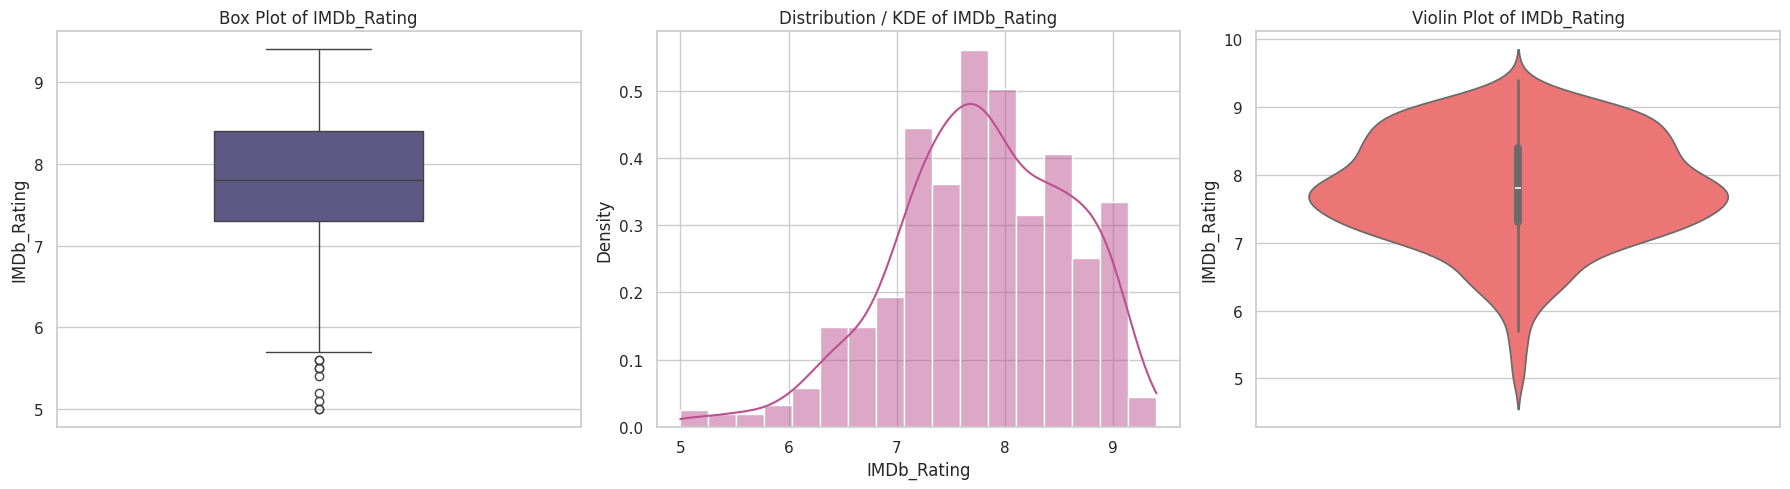

=== STATISTICS FOR GROSS_EARNINGS ===
Mean: 3.50 | Median: 3.17 | Mode: 2.78
Range: 6.76 | Variance: 3.76 | Std Dev: 1.94 | IQR: 1.67
--------------------------------------------------


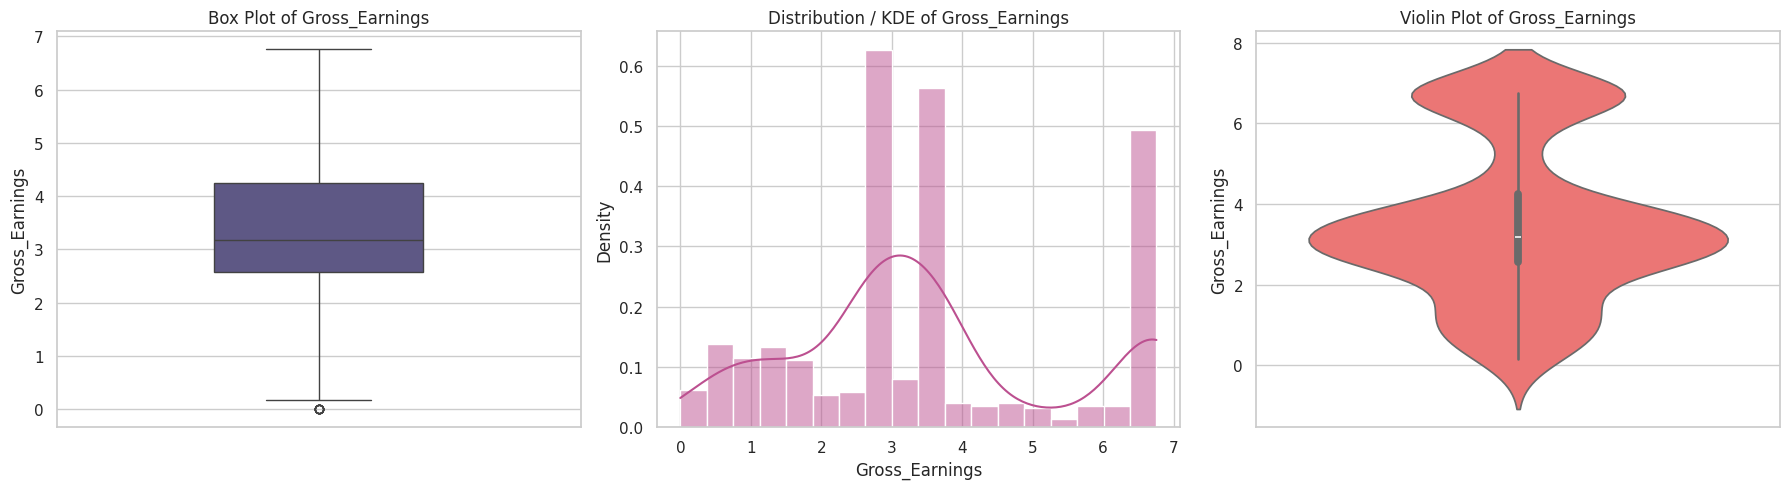

=== STATISTICS FOR NUM_VOTES ===
Mean: 82501.43 | Median: 60144.50 | Mode: 25060.00
Range: 690560.00 | Variance: 6165611431.23 | Std Dev: 78521.41 | IQR: 88404.25
--------------------------------------------------


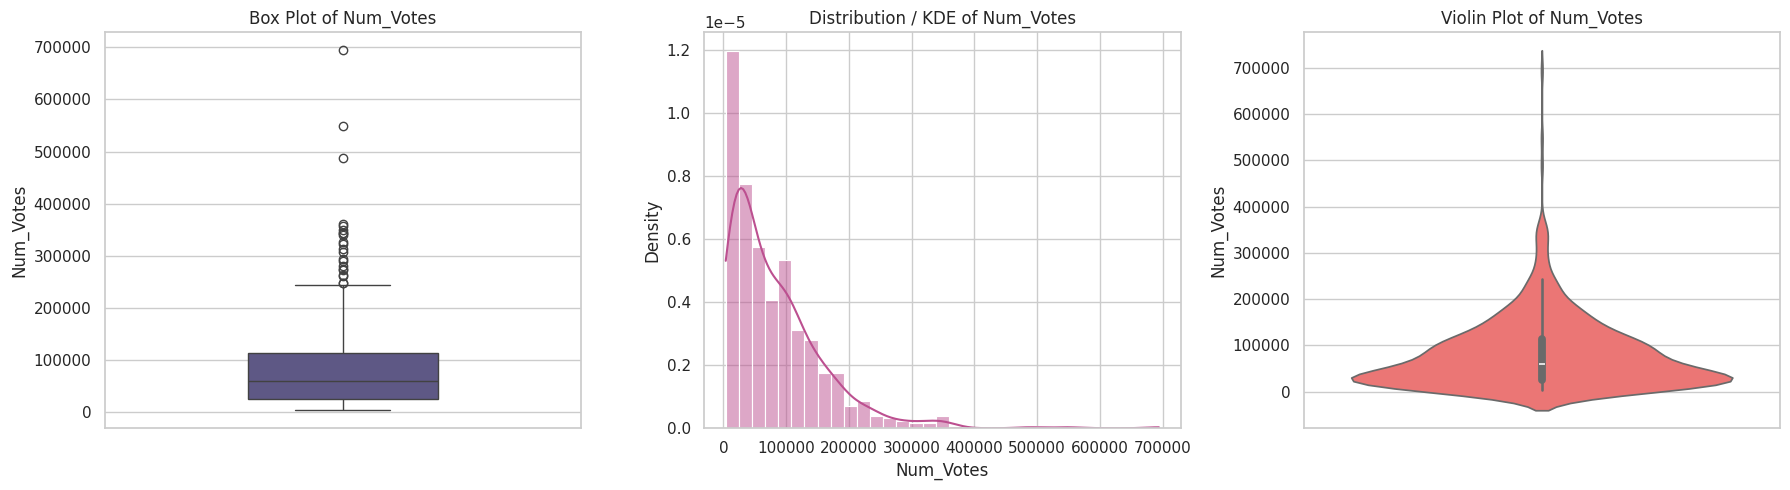

=== STATISTICS FOR RUNTIME_MINUTES ===
Mean: 165.10 | Median: 162.00 | Mode: 239.00
Range: 134.00 | Variance: 744.80 | Std Dev: 27.29 | IQR: 38.00
--------------------------------------------------


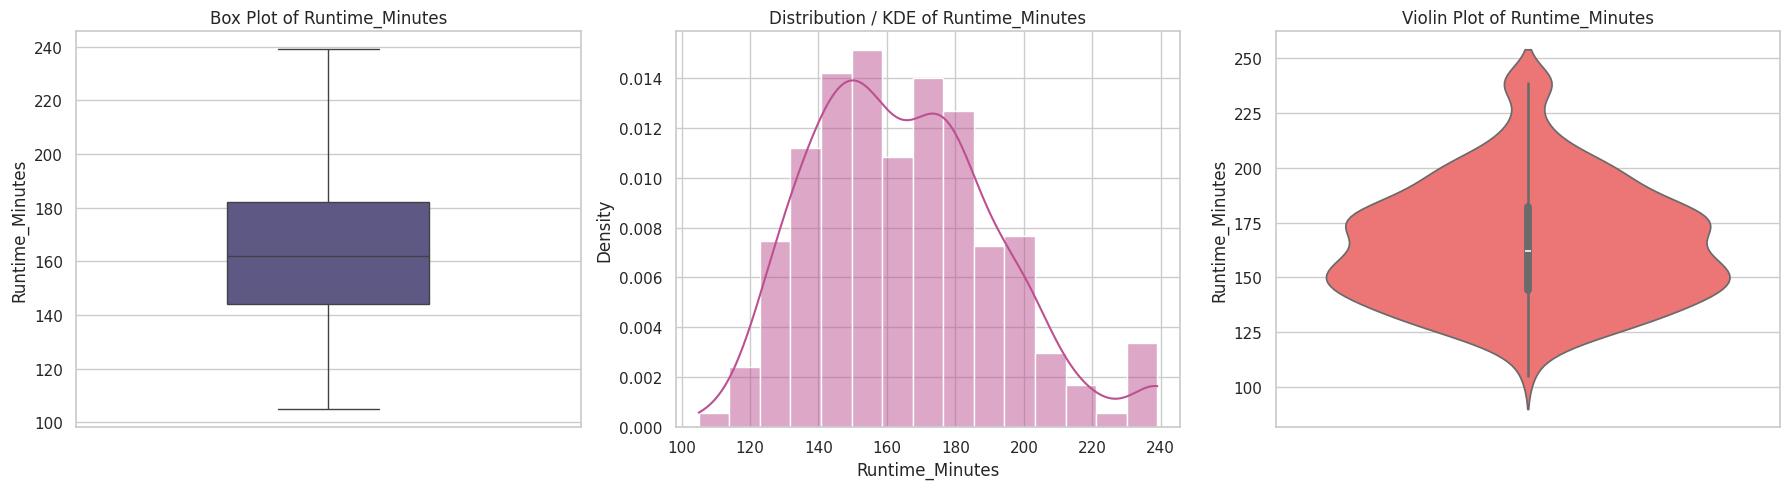

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetics for plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10

continuous_vars = ["IMDb_Rating", "Gross_Earnings", "Num_Votes", "Runtime_Minutes"]

for var in continuous_vars:
    # 1. Calculate Descriptive Statistical Metrics
    mean_val = df[var].mean()
    median_val = df[var].median()
    mode_val = df[var].mode()[0]
    range_val = df[var].max() - df[var].min()
    var_val = df[var].var()
    std_val = df[var].std()
    q1 = df[var].quantile(0.25)
    q3 = df[var].quantile(0.75)
    iqr_val = q3 - q1

    print(f"=== STATISTICS FOR {var.upper()} ===")
    print(f"Mean: {mean_val:.2f} | Median: {median_val:.2f} | Mode: {mode_val:.2f}")
    print(f"Range: {range_val:.2f} | Variance: {var_val:.2f} | Std Dev: {std_val:.2f} | IQR: {iqr_val:.2f}")
    print("-" * 50)

    # 2. Plotting Visualizations
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Box-plot
    sns.boxplot(y=df[var], ax=axes[0], color="#58508d", width=0.4)
    axes[0].set_title(f"Box Plot of {var}")

    # Histogram + KDE
    sns.histplot(df[var], kde=True, ax=axes[1], color="#bc5090", stat="density")
    axes[1].set_title(f"Distribution / KDE of {var}")

    # Violin plot
    sns.violinplot(y=df[var], ax=axes[2], color="#ff6361")
    axes[2].set_title(f"Violin Plot of {var}")

    plt.tight_layout()
    plt.show()


### Categorical Variables
For categorical variables (`Region`, `Certificate`, and the primary `Genre` of the film), we calculate the **frequency counts** and **percentages**, and visualize them using **Count plots**, **Bar plots**, and **Pie charts**.

=== FREQUENCY DISTRIBUTION OF REGION ===
   Region  Count  Percentage
Bollywood    300        50.0
Tollywood    300        50.0
--------------------------------------------------


/tmp/ipykernel_2080/2975456096.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette="coolwarm", ax=axes[0], order=df[var].value_counts().index)


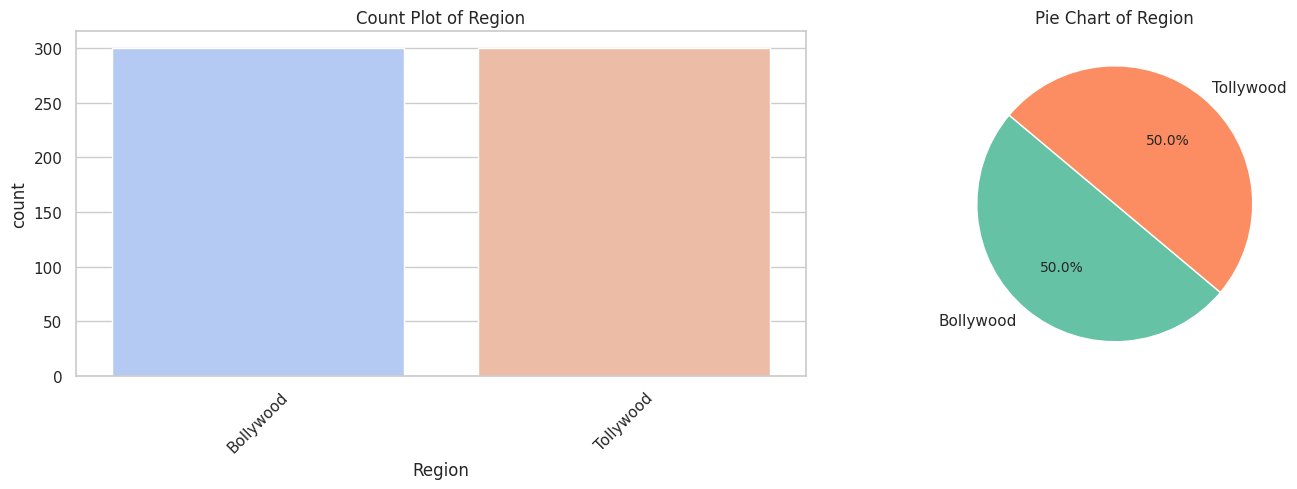

=== FREQUENCY DISTRIBUTION OF CERTIFICATE ===
Certificate  Count  Percentage
         UA    418   69.666667
          U    139   23.166667
          A     43    7.166667
--------------------------------------------------


/tmp/ipykernel_2080/2975456096.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette="coolwarm", ax=axes[0], order=df[var].value_counts().index)


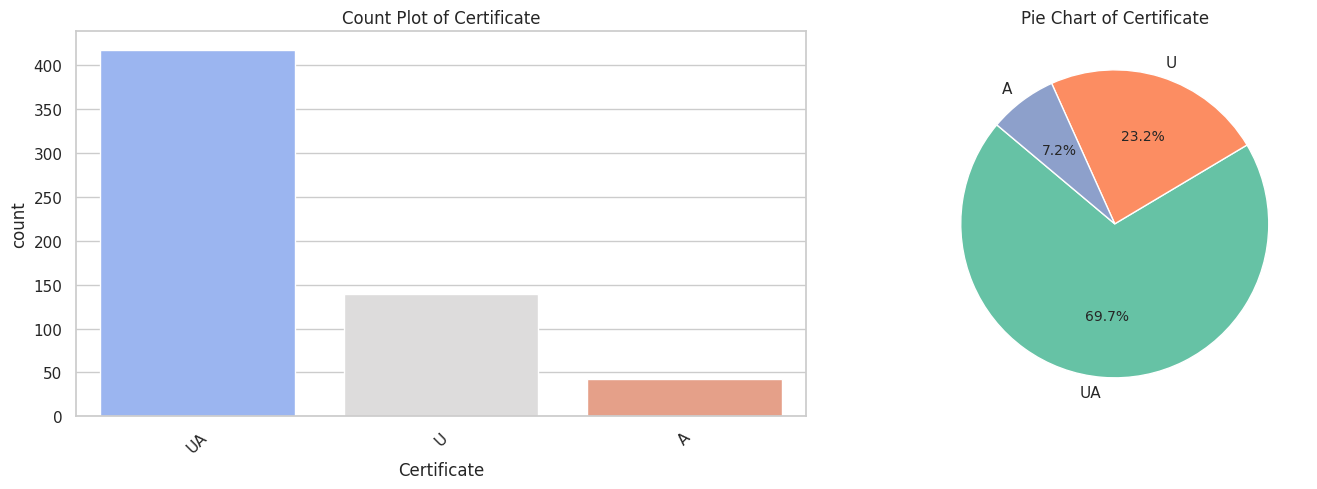

=== FREQUENCY DISTRIBUTION OF PRIMARY_GENRE ===
Primary_Genre  Count  Percentage
       Action    331   55.166667
       Comedy    112   18.666667
        Drama    107   17.833333
    Biography     41    6.833333
        Crime      9    1.500000
--------------------------------------------------


/tmp/ipykernel_2080/2975456096.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette="coolwarm", ax=axes[0], order=df[var].value_counts().index)


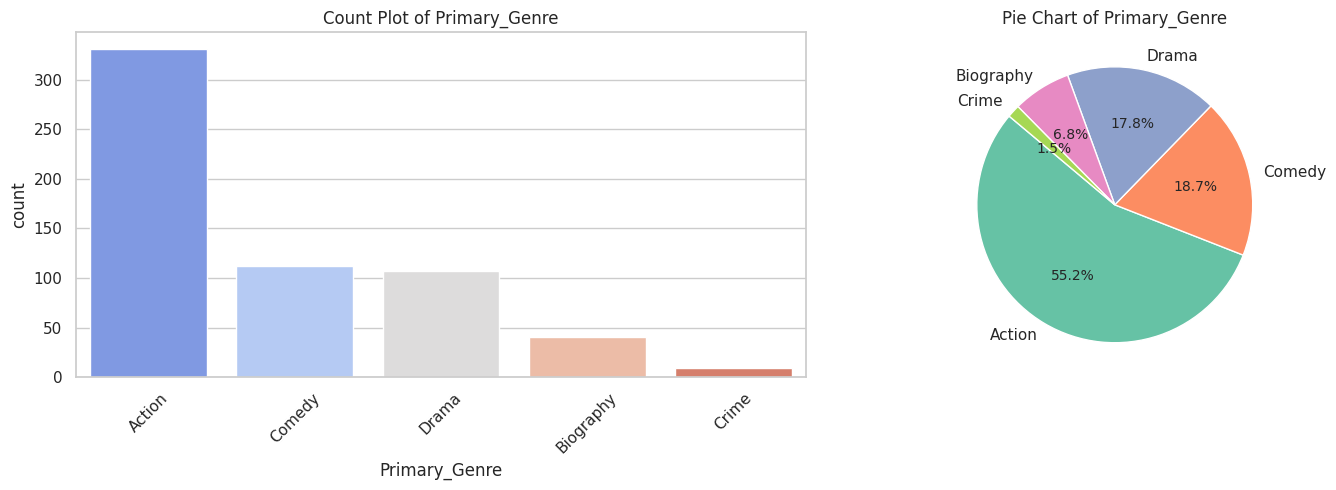

In [ ]:
# Extract primary genre (first genre listed before comma)
df["Primary_Genre"] = df["Genre"].apply(lambda x: x.split(",")[0].strip())

categorical_vars = ["Region", "Certificate", "Primary_Genre"]

for var in categorical_vars:
    # 1. Frequency and Percentage Table
    freq_table = df[var].value_counts().reset_index()
    freq_table.columns = [var, "Count"]
    freq_table["Percentage"] = (freq_table["Count"] / len(df)) * 100

    print(f"=== FREQUENCY DISTRIBUTION OF {var.upper()} ===")
    print(freq_table.to_string(index=False))
    print("-" * 50)

    # 2. Visualizations (Bar Chart and Pie Chart)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Count / Bar plot
    sns.countplot(data=df, x=var, palette="coolwarm", ax=axes[0], order=df[var].value_counts().index)
    axes[0].set_title(f"Count Plot of {var}")
    axes[0].tick_params(axis='x', rotation=45)

    # Pie chart
    top_n = df[var].value_counts()
    # If too many categories (like Genre), group smaller ones into 'Others'
    if len(top_n) > 5:
        top_categories = top_n.head(4)
        others_sum = pd.Series([top_n.iloc[4:].sum()], index=["Others"])
        top_n_pie = pd.concat([top_categories, others_sum])
    else:
        top_n_pie = top_n

    axes[1].pie(top_n_pie, labels=top_n_pie.index, autopct='%1.1f%%', colors=sns.color_palette("Set2"), startangle=140)
    axes[1].set_title(f"Pie Chart of {var}")

    plt.tight_layout()
    plt.show()


## 📈 Step 5: Bivariate & Multivariate Analysis

This section analyzes relationships between variables as requested by the problem statement (specifically comparing ratings and gross income with other variables):

### 1. Continuous and Categorical Variables (GroupBy & Pivot Tables)
We analyze the average ratings and gross earnings by Region (Bollywood vs. Tollywood) and Genre.

=== REGIONAL STATISTICS (RATING & GROSS) ===
      Region IMDb_Rating                  Gross_Earnings                 
                    mean median       std           mean median       std
0  Bollywood    7.812000   7.85  0.840393       3.805750   3.61  1.910781
1  Tollywood    7.754667   7.70  0.782679       3.185987   2.78  1.921981
--------------------------------------------------
=== PIVOT TABLE: MEAN GROSS ($M) BY GENRE & REGION ===
Region         Bollywood  Tollywood
Primary_Genre                      
Action          3.705250   3.393869
Biography       4.145458   1.930909
Comedy          4.290521   1.960357
Crime           1.620000   0.000000
Drama           3.530552   3.189417
--------------------------------------------------


/tmp/ipykernel_2080/1585497276.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Region", y="IMDb_Rating", palette="Set2", ax=axes[0])
/tmp/ipykernel_2080/1585497276.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="Region", y="Gross_Earnings", palette="Set2", ax=axes[1], ci=None)
/tmp/ipykernel_2080/1585497276.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Region", y="Gross_Earnings", palette="Set2", ax=axes[1], ci=None)


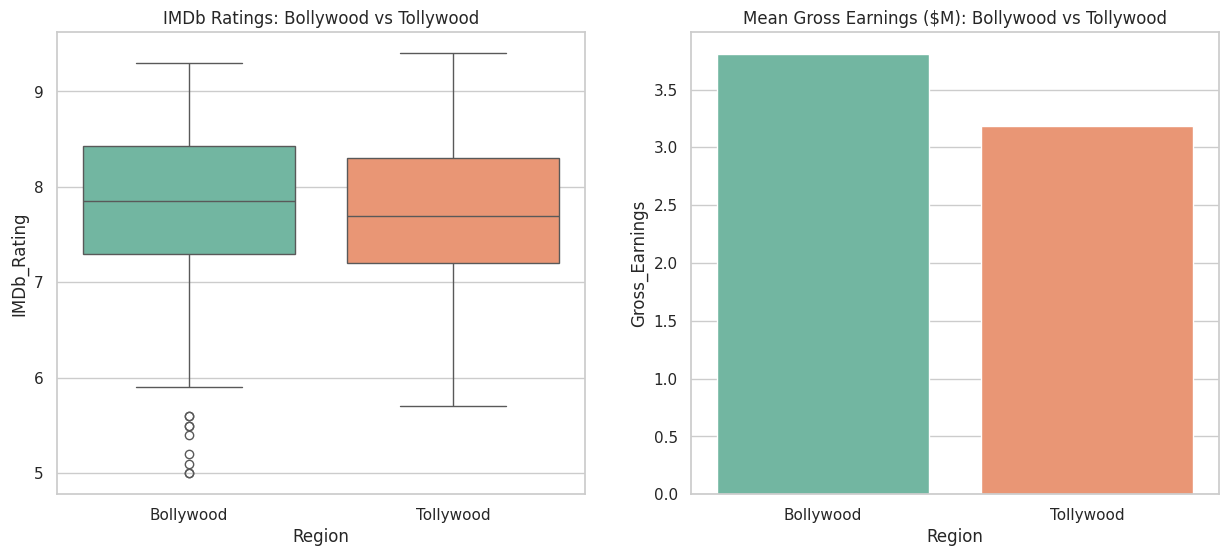

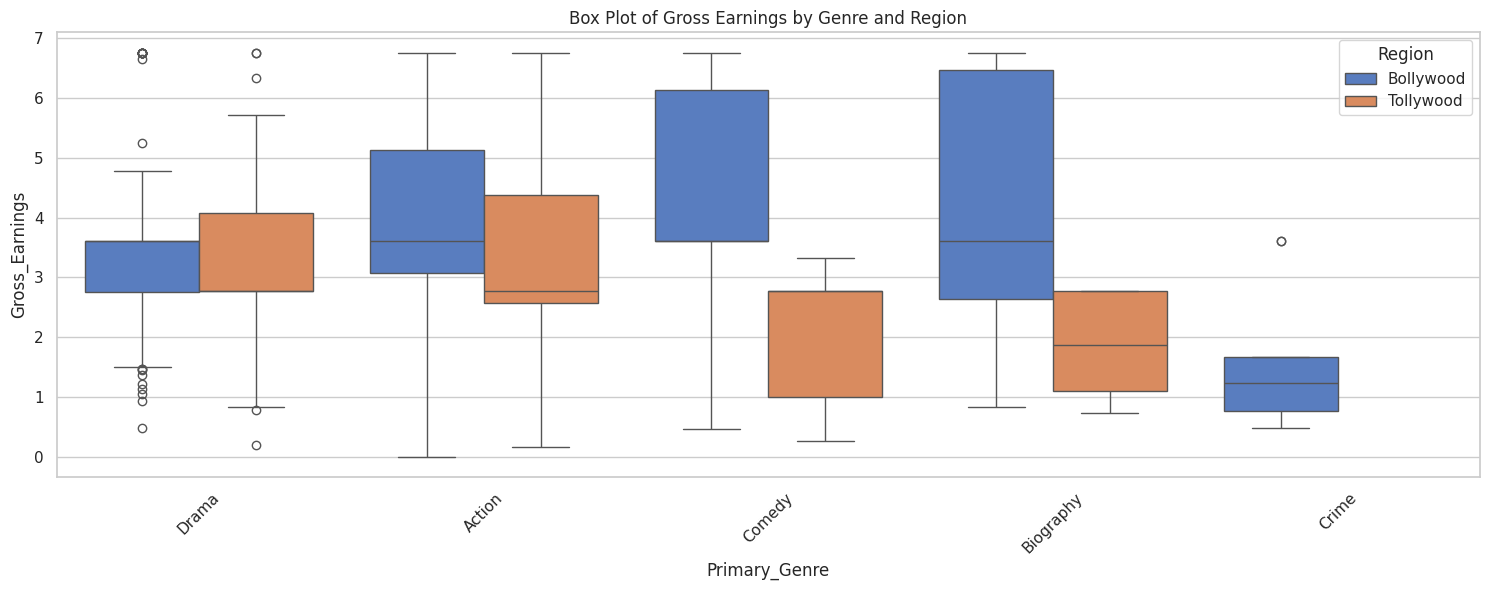

In [ ]:
# GroupBy: Ratings and Gross by Region
region_group = df.groupby("Region")[["IMDb_Rating", "Gross_Earnings"]].agg(["mean", "median", "std"]).reset_index()
print("=== REGIONAL STATISTICS (RATING & GROSS) ===")
print(region_group)
print("-" * 50)

# Pivot Table: Average Gross Earnings by Genre and Region
genre_region_pivot = df.pivot_table(
    values="Gross_Earnings",
    index="Primary_Genre",
    columns="Region",
    aggfunc="mean"
).fillna(0)
print("=== PIVOT TABLE: MEAN GROSS ($M) BY GENRE & REGION ===")
print(genre_region_pivot)
print("-" * 50)

# Plots: Ratings & Gross across Bollywood and Tollywood
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot of Ratings by Region
sns.boxplot(data=df, x="Region", y="IMDb_Rating", palette="Set2", ax=axes[0])
axes[0].set_title("IMDb Ratings: Bollywood vs Tollywood")

# Barplot of Gross Earnings by Region
sns.barplot(data=df, x="Region", y="Gross_Earnings", palette="Set2", ax=axes[1], ci=None)
axes[1].set_title("Mean Gross Earnings ($M): Bollywood vs Tollywood")
plt.show()

# Boxplot of Gross Earnings by Genre
plt.figure(figsize=(15, 6))
sns.boxplot(data=df, x="Primary_Genre", y="Gross_Earnings", hue="Region", palette="muted")
plt.title("Box Plot of Gross Earnings by Genre and Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 2. Continuous to Continuous Variables (Correlation Plot & Scatter Plots)
We analyze how continuous features correlate with one another, plotting a **Correlation Matrix Heatmap** and **Scatter plots** with regression lines.

=== PEARSON CORRELATION MATRIX ===
                 IMDb_Rating  Gross_Earnings  Num_Votes  Runtime_Minutes  \
IMDb_Rating         1.000000       -0.079112   0.216757         0.104428   
Gross_Earnings     -0.079112        1.000000   0.274442        -0.005224   
Num_Votes           0.216757        0.274442   1.000000         0.073715   
Runtime_Minutes     0.104428       -0.005224   0.073715         1.000000   
Release_Year        0.004411        0.034745   0.024995        -0.017044   

                 Release_Year  
IMDb_Rating          0.004411  
Gross_Earnings       0.034745  
Num_Votes            0.024995  
Runtime_Minutes     -0.017044  
Release_Year         1.000000  
--------------------------------------------------


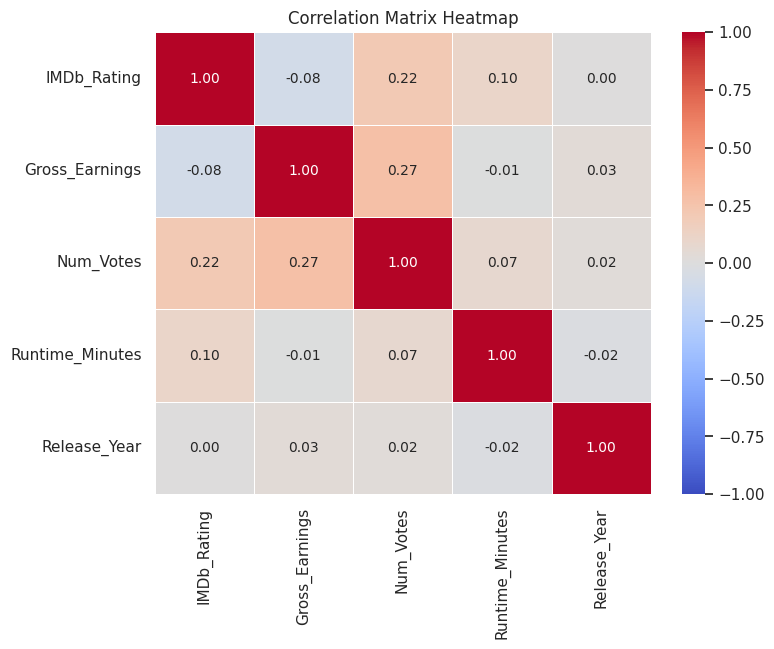

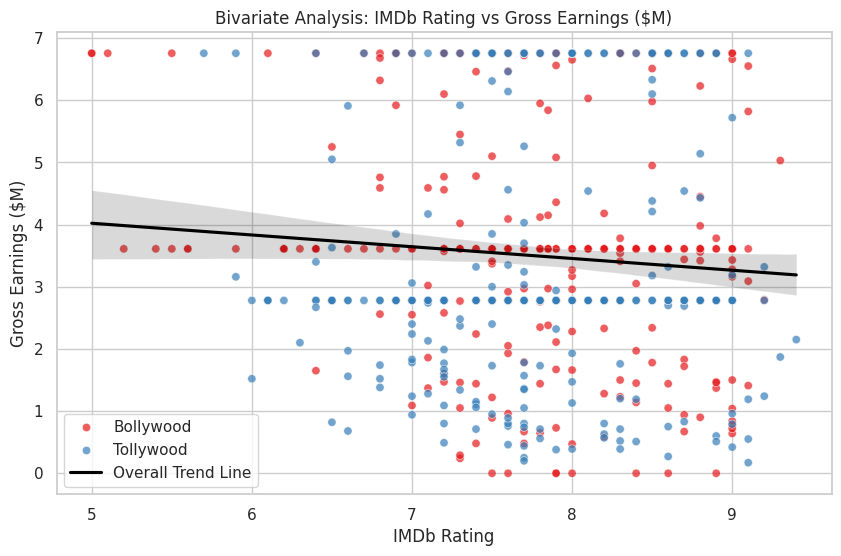

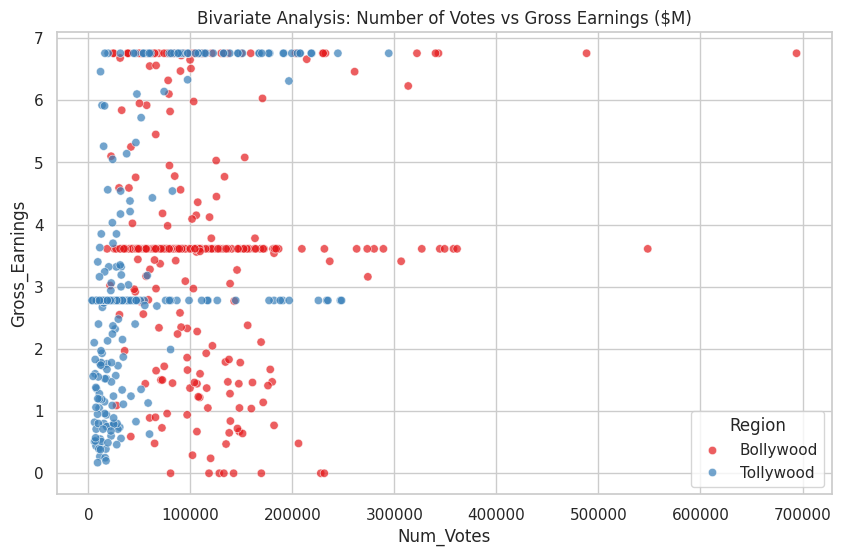

In [ ]:
# Calculate Pearson Correlation Matrix
correlation_matrix = df[["IMDb_Rating", "Gross_Earnings", "Num_Votes", "Runtime_Minutes", "Release_Year"]].corr()
print("=== PEARSON CORRELATION MATRIX ===")
print(correlation_matrix)
print("-" * 50)

# 1. Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix Heatmap")
plt.show()

# 2. Scatter plot with regression line: Rating vs Gross Earnings
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="IMDb_Rating", y="Gross_Earnings", hue="Region", palette="Set1", alpha=0.7)
sns.regplot(data=df, x="IMDb_Rating", y="Gross_Earnings", scatter=False, color="black", label="Overall Trend Line")
plt.title("Bivariate Analysis: IMDb Rating vs Gross Earnings ($M)")
plt.xlabel("IMDb Rating")
plt.ylabel("Gross Earnings ($M)")
plt.legend()
plt.show()

# Scatter plot: Votes vs Gross Earnings
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Num_Votes", y="Gross_Earnings", hue="Region", palette="Set1", alpha=0.7)
plt.title("Bivariate Analysis: Number of Votes vs Gross Earnings ($M)")
plt.show()


### 3. Categorical to Categorical Variables (Crosstabs)
We compute a contingency table using `pd.crosstab` to compare the distribution of primary film genres across Bollywood and Tollywood.

=== CROSSTAB: FILM COUNT BY GENRE AND REGION ===
Region         Bollywood  Tollywood
Primary_Genre                      
Action               100        231
Biography             30         11
Comedy                84         28
Crime                  9          0
Drama                 77         30

=== PERCENTAGE SHARE (%) OF GENRES BY REGION ===
Region         Bollywood  Tollywood
Primary_Genre                      
Action             33.33      77.00
Biography          10.00       3.67
Comedy             28.00       9.33
Crime               3.00       0.00
Drama              25.67      10.00
--------------------------------------------------


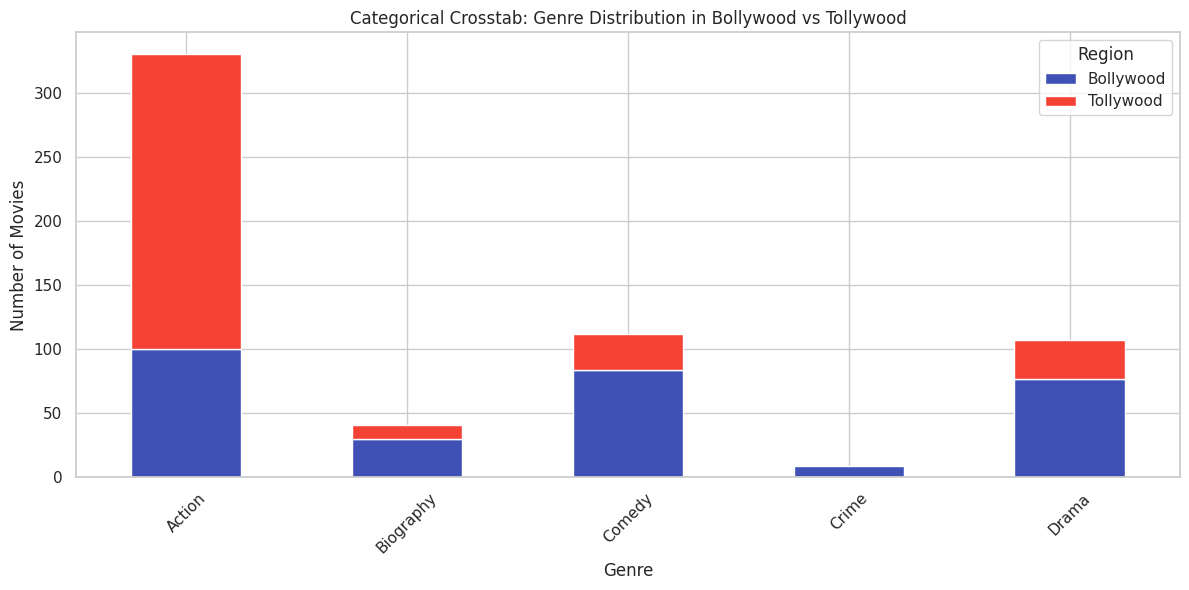

In [ ]:
# Crosstab: Genre vs Region
genre_region_cross = pd.crosstab(index=df["Primary_Genre"], columns=df["Region"])
genre_region_perc = pd.crosstab(index=df["Primary_Genre"], columns=df["Region"], normalize="columns") * 100

print("=== CROSSTAB: FILM COUNT BY GENRE AND REGION ===")
print(genre_region_cross)
print("\n=== PERCENTAGE SHARE (%) OF GENRES BY REGION ===")
print(genre_region_perc.round(2))
print("-" * 50)

# Stacked Bar Plot: Genre Distribution by Region
genre_region_cross.plot(kind="bar", stacked=True, figsize=(12, 6), color=["#3f51b5", "#f44336"])
plt.title("Categorical Crosstab: Genre Distribution in Bollywood vs Tollywood")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.legend(title="Region")
plt.tight_layout()
plt.show()


## 🎯 Final Insights

Based on the exploratory data analysis of the IMDb movie dataset, the following insights were observed:

- The dataset includes movies from both **Bollywood** and **Tollywood**, enabling a comparative analysis.
- IMDb ratings and gross earnings vary across different genres and regions.
- Some variables contained missing values and outliers, which were handled during the data cleaning process.
- Correlation analysis helped identify relationships between IMDb ratings, gross earnings, number of votes, runtime, and release year.
- Data visualizations revealed patterns in movie performance and audience engagement.
- Grouping and crosstab analysis provided a better understanding of genre distribution across regions.

These insights demonstrate how Exploratory Data Analysis (EDA) can transform raw data into meaningful information that supports data-driven decision-making.

## ✅ Conclusion

This project successfully demonstrated an end-to-end Exploratory Data Analysis (EDA) workflow using IMDb movie data.

### Skills Demonstrated

- Python Programming
- Web Scraping
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Statistical Analysis
- Data Visualization
- Pandas
- NumPy
- Matplotlib
- Seaborn

This project strengthened my understanding of the complete EDA pipeline, from collecting raw data to extracting meaningful insights through statistical analysis and visualization.